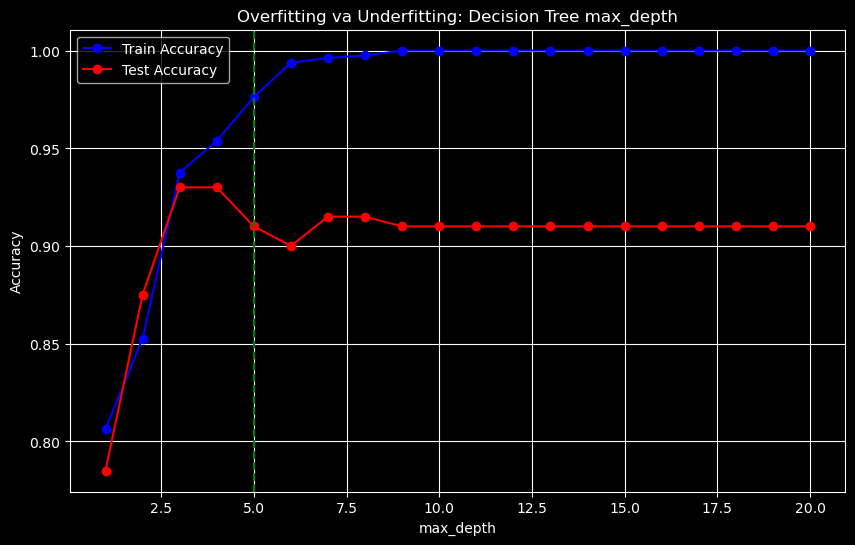

max_depth= 1 | Train=0.8063 | Test=0.7850 | Gap=0.0212
max_depth= 2 | Train=0.8525 | Test=0.8750 | Gap=0.0225
max_depth= 3 | Train=0.9375 | Test=0.9300 | Gap=0.0075
max_depth= 4 | Train=0.9537 | Test=0.9300 | Gap=0.0237
max_depth= 5 | Train=0.9762 | Test=0.9100 | Gap=0.0662
max_depth= 6 | Train=0.9938 | Test=0.9000 | Gap=0.0938
max_depth= 7 | Train=0.9962 | Test=0.9150 | Gap=0.0812
max_depth= 8 | Train=0.9975 | Test=0.9150 | Gap=0.0825
max_depth= 9 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=10 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=11 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=12 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=13 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=14 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=15 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=16 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=17 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=18 | Train=1.0000 | Test=0.9100 | Gap=0.0900
max_depth=

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Sun'iy dataset yaratish (overfittingni oson ko'rsatish uchun)
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=15,
    random_state=42
)

# 2. Train / Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Har xil max_depth uchun train va test accuracy hisoblash
train_accuracies = []
test_accuracies = []
depths = list(range(1, 21))

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Train accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_acc)

    # Test accuracy
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_acc)

# 4. Grafik chizish (eng muhim qism)
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o', color='blue')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='o', color='red')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting va Underfitting: Decision Tree max_depth')
plt.legend()
plt.grid(True)
plt.axvline(x=5, color='green', linestyle='--', label='Taxminiy optimal nuqta (overfitting boshlanishi)')  # o'zing aniqlagan joyga o'zgartir
plt.show()

# Natijalarni konsolga chiqar
for d, tr, te in zip(depths, train_accuracies, test_accuracies):
    print(f"max_depth={d:2d} | Train={tr:.4f} | Test={te:.4f} | Gap={abs(tr-te):.4f}")